In [ ]:
%pip install puremacro


# One shock, six identifications

**What happens to US industrial production after an uncertainty shock?**
Bloom (2009) says activity drops and rebounds; a large literature since
says the drop is deep and persistent; a smaller one says it is small or
even absent once you change the identifying assumption. This notebook runs
**six identification schemes on one frozen monthly dataset** — uncertainty
(EPU), industrial production, employment, the federal funds rate, monthly
1954–2025 — so every disagreement you see is *assumption*, not data. It is
the teaching companion to the package's uncertainty-identification
spec-curve pipeline (`tools/run_uncertainty_ident_spec_curve.py`), which
runs the same menu plus four more schemes across a full grid of proxies,
samples and detrendings.

## The identification problem in one equation

Every scheme starts from the same reduced-form VAR in
$x_t = (u_t, ip_t, emp_t, ffr_t)'$:
$$ x_t = A_1 x_{t-1} + \cdots + A_6 x_{t-6} + e_t, \qquad
   e_t = B\,\varepsilon_t, \qquad \Sigma_e = BB'. $$
The data pin down $\Sigma_e$ (10 numbers) but $B$ has 16 — the missing 6
are the identifying assumptions. Each scheme fills them differently:

| scheme | the assumption, in one honest sentence |
|---|---|
| **Cholesky (u first)** | uncertainty responds to nothing within the month; everything responds to uncertainty |
| **Sign restrictions** | an uncertainty shock raises $u$ and lowers $ip$ for 3 months — and *any* rotation that does so is admissible |
| **Narrative (Type I)** | as sign, plus: the shock was *positive* in Oct-1987, Sep-2001, Sep-2008, Mar-2020 (Antolín-Díaz & Rubio-Ramírez 2018) |
| **Narrative (Type II)** | as Type I, plus: the shock was the *most important driver* of $u$ itself in Sep-2008 and Mar-2020 — and draws are reweighted by how easily they satisfy this |
| **Max-share** | the uncertainty shock is whatever explains the largest share of $u$'s forecast-error variance at 12 months (no exclusion restrictions at all) |
| **Proxy SVAR** | a *second* uncertainty measure (JLN) is correlated with the true shock and uncorrelated with all others (Stock-Watson 2018; Mertens-Ravn 2013) |

**Intuition.** None of these schemes uses more data than the others — they
*believe differently*. Cholesky buys a point estimate with a timing dogma.
Sign restrictions retreat to a *set* of models and hand you its spread.
Narrative restrictions shrink that set with historical judgment calls —
and the Type II version finally makes the AD-RR importance weights do real
work: with only Type-I event signs the weights are constant by
construction, so the effective sample size (ESS) is just the count of
surviving draws; a dominance restriction makes some rotations *barely*
admissible and others comfortably so, and ESS starts measuring that.
Max-share and proxy identification replace institutional beliefs with
statistical ones. Keep score of what each buys and what it costs.

## Setup — one frozen dataset

The panel ships with the package (`speccurve17_panel.csv`, frozen by
`tools/gen_notebook_data_speccurve17.py` as a byte-identical copy of the
research pipeline's `panel_monthly.csv`): monthly EPU / WUI / JLN / VIX
uncertainty proxies (standardized), 100×log industrial production and
employment, and the federal funds rate, from key-free public sources. We
use the pipeline's baseline cell: proxy = EPU, full common sample,
linear-trend detrending of the activity variables.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.var.identify import (
    NarrativeRestriction,
    cholesky as cholesky_svar,
    identify_maxshare,
    narrative_sign_svar,
    proxy as proxy_svar,
    sign_restrictions as sign_restriction_svar,
)

P, H, CI = 6, 24, 0.90

panel = load_csv("speccurve17_panel")
panel["date"] = pd.to_datetime(panel["date"])
panel = panel.set_index("date")

df = panel[["epu", "ip", "emp", "ffr"]].dropna()
expected = pd.date_range(df.index.min(), df.index.max(), freq="MS")
assert len(expected) == len(df) and (expected == df.index).all(), "gaps!"


def linear_detrend(x):
    t = np.arange(len(x), dtype=float)
    X = np.column_stack([np.ones_like(t), t])
    return x - X @ np.linalg.lstsq(X, x, rcond=None)[0]


Y = np.column_stack([
    df["epu"].to_numpy(),
    linear_detrend(df["ip"].to_numpy()),
    linear_detrend(df["emp"].to_numpy()),
    df["ffr"].to_numpy(),
])
dates = df.index
print(f"baseline dataset: {dates.min().date()} .. {dates.max().date()}, "
      f"T={len(df)} months")

baseline dataset: 1954-07-01 .. 2025-11-01, T=857 months


Two shared conventions, identical to the pipeline: the traditional **sign
pattern** (uncertainty up, activity down, for the first 3 months; `emp`
and `ffr` unrestricted), and **unit-effect normalization** — every path is
scaled so the labelled uncertainty shock moves $u$ by +1 standard
deviation on impact, making magnitudes comparable across schemes.

In [2]:
SIGN_PATTERN = {h: [1, -1, 0, 0] for h in range(3)}
EVENTS = ["1987-10-01", "2001-09-01", "2008-09-01", "2020-03-01"]
HD_EVENTS = ["2008-09-01", "2020-03-01"]     # Lehman, COVID


def unit_effect(path_u_impact, resp, lo, hi):
    """Scale so the shock's impact on u is +1 (band swap if k<0)."""
    assert abs(path_u_impact) > 1e-3, "degenerate loading on u"
    k = 1.0 / path_u_impact
    resp = np.asarray(resp) * k
    lo = None if lo is None else np.asarray(lo) * k
    hi = None if hi is None else np.asarray(hi) * k
    if k < 0 and lo is not None:
        lo, hi = hi, lo
    return resp, lo, hi


def ar_innovations(x, p=6):
    """AR(p) residuals, zero-padded at the front (for the proxy)."""
    Xl = np.column_stack([np.ones(len(x) - p)]
                         + [x[p - l - 1:len(x) - l - 1] for l in range(p)])
    b = np.linalg.lstsq(Xl, x[p:], rcond=None)[0]
    z = np.zeros_like(x)
    z[p:] = x[p:] - Xl @ b
    return z

## Run the menu

Each block returns the IP response path (percent, months 0–24) with a 90%
band where the scheme provides one. Draw counts are the pipeline's quick
tier — enough for a stable picture in seconds, not publication bands.

In [3]:
runs = {}

r = cholesky_svar(Y, p=P, horizon=H, n_boot=50, ci=CI, seed=42)
runs["cholesky"] = unit_effect(r.irf_point[0, 0, 0], r.irf_point[:, 1, 0],
                               r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])

r = sign_restriction_svar(Y, p=P, horizon=H, restrictions=SIGN_PATTERN,
                          n_draws=600, ci=CI, seed=42)
runs["sign"] = unit_effect(r.irf_median[0, 0, 0], r.irf_median[:, 1, 0],
                           r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
print(f"sign: {r.n_accepted}/600 rotations accepted")

r = narrative_sign_svar(Y, p=P, horizon=H, sign_matrix=SIGN_PATTERN,
                        restrictions=[(ev, 0, +1) for ev in EVENTS],
                        dates=dates, n_draws=600, ci=CI, seed=42)
runs["narrative I"] = unit_effect(r.irf_median[0, 0, 0], r.irf_median[:, 1, 0],
                                  r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
print(f"narrative I : {r.n_narrative_accepted}/{r.n_traditional_accepted} "
      f"draws survive the events, ESS={r.ess:.0f} (== count: Type-I weights "
      "are constant)")

restr2 = ([(ev, 0, +1) for ev in EVENTS]
          + [NarrativeRestriction(kind="hd_dominance", date=ev, shock=0,
                                  variable=0, window=0, dominance="most")
             for ev in HD_EVENTS])
r = narrative_sign_svar(Y, p=P, horizon=H, sign_matrix=SIGN_PATTERN,
                        restrictions=restr2, dates=dates, n_draws=600,
                        ci=CI, seed=42)
runs["narrative II"] = unit_effect(r.irf_median[0, 0, 0], r.irf_median[:, 1, 0],
                                   r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
ess2, nnarr2 = r.ess, r.n_narrative_accepted
print(f"narrative II: {nnarr2}/{r.n_traditional_accepted} draws survive, "
      f"ESS={ess2:.1f} < count: the dominance restriction reweights")

r = identify_maxshare(Y, p=P, target_idx=0, max_fev_at=12, horizon=H,
                      n_bootstrap=50, ci=CI, seed=42)
runs["max-share"] = unit_effect(r.irfs[0, 0, 0], r.irfs[:, 1, 0],
                                r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])

z = np.zeros(len(df))
jln = panel["jln"].reindex(dates)
avail = jln.notna().to_numpy()
z[avail] = ar_innovations(jln.to_numpy()[avail])
r = proxy_svar(Y, p=P, horizon=H, instrument_series=z, shock_target_idx=0,
               n_boot=50, ci=CI, seed=42)
runs["proxy (JLN)"] = unit_effect(r.irf_point[0, 0, 0], r.irf_point[:, 1, 0],
                                  r.irf_lower[:, 1, 0], r.irf_upper[:, 1, 0])
print(f"proxy: first-stage F = {r.first_stage_F:.1f}")

sign: 137/600 rotations accepted
narrative I : 127/159 draws survive the events, ESS=127 (== count: Type-I weights are constant)


narrative II: 53/159 draws survive, ESS=23.7 < count: the dominance restriction reweights


proxy: first-stage F = 6.0


## The menu, side by side

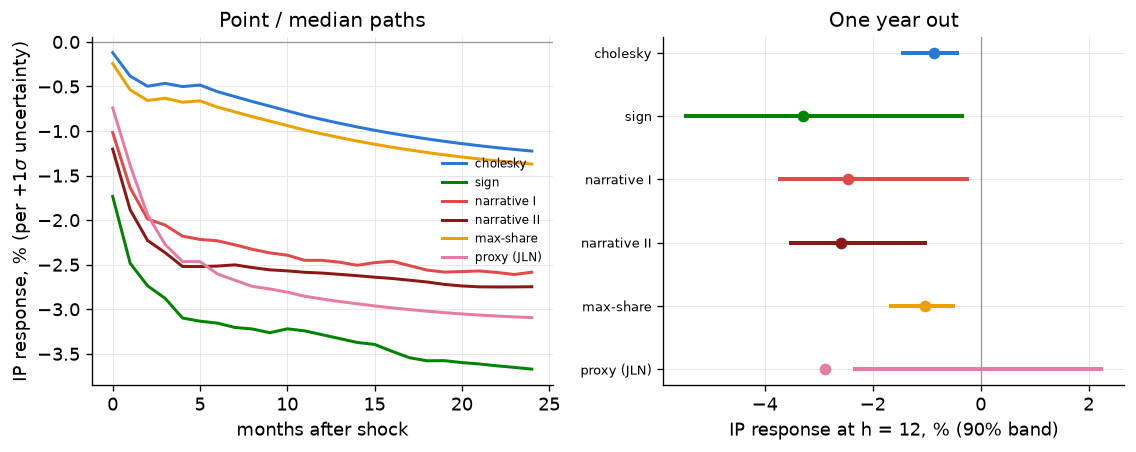

{'cholesky': np.float64(-0.87), 'sign': np.float64(-3.29), 'narrative I': np.float64(-2.45), 'narrative II': np.float64(-2.59), 'max-share': np.float64(-1.03), 'proxy (JLN)': np.float64(-2.89)}


In [4]:
COLORS = {"cholesky": "#2a78d6", "sign": "#008300",
          "narrative I": "#e34948", "narrative II": "#8c1815",
          "max-share": "#eda100", "proxy (JLN)": "#e87ba4"}
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
hgrid = np.arange(H + 1)
for name, (resp, lo, hi) in runs.items():
    axes[0].plot(hgrid, resp, lw=1.8, color=COLORS[name], label=name)
axes[0].axhline(0, color="0.6", lw=0.8)
axes[0].set_xlabel("months after shock"); axes[0].set_ylabel(
    "IP response, % (per +1$\\sigma$ uncertainty)")
axes[0].set_title("Point / median paths"); axes[0].legend(fontsize=7)

ypos = np.arange(len(runs))[::-1]
for y, (name, (resp, lo, hi)) in zip(ypos, runs.items()):
    c = COLORS[name]
    if lo is not None:
        axes[1].plot([lo[12], hi[12]], [y, y], color=c, lw=2.4,
                     solid_capstyle="butt")
    axes[1].plot(resp[12], y, "o", color=c, ms=6)
axes[1].axvline(0, color="0.6", lw=0.8)
axes[1].set_yticks(ypos); axes[1].set_yticklabels(list(runs), fontsize=8)
axes[1].set_xlabel("IP response at h = 12, % (90% band)")
axes[1].set_title("One year out")
plt.tight_layout(); plt.show()

h12 = {k: v[0][12] for k, v in runs.items()}
print({k: round(v, 2) for k, v in h12.items()})
assert all(v < 0 for v in h12.values()), "all six h=12 responses negative"

**Reading the figure.** All six schemes agree on the *sign* — industrial
production is lower a year after an uncertainty shock — but the magnitude
spans roughly a factor of four, and the bands range from a tight Cholesky
ribbon (bought with the timing dogma) to the wide sign-restriction set
(bought with honesty about rotations). The narrative restrictions tighten
the sign set from inside; the Type-II dominance restriction tightens it
further and *reweights* it — its ESS is well below its accepted-draw
count, which is the diagnostic telling you the restriction is genuinely
informative rather than redundant.

**The spec-curve punchline.** This notebook holds the data fixed and moves
the assumption. The research pipeline moves *everything*: 207
estimated cells across 12 schemes × 4 proxies × 3 samples × 2 detrendings.
In that grid, scheme dummies explain R² = 0.24 of the variation in peak
responses and the data dimensions R² = 0.38 — identification choice
rivals data choice, and every scheme family with *economic* restrictions
finds a negative peak. When a paper reports "the" effect of uncertainty,
ask which cell of this grid it lives in.

## Your turn — pick your own history

The four event months are themselves a specification choice (the pipeline
sweeps all leave-one-out configurations; `event_sweep.csv`). Choose your
own event set below: drop the one you find least like an *uncertainty*
shock, or add "2011-08-01" (the US debt-ceiling standoff) — a month the
literature argues about.

In [5]:
# ← Change this: which months was the uncertainty shock POSITIVE in?
EVENTS_TRY = ["1987-10-01", "2008-09-01", "2020-03-01"]

r_try = narrative_sign_svar(Y, p=P, horizon=H, sign_matrix=SIGN_PATTERN,
                            restrictions=[(ev, 0, +1) for ev in EVENTS_TRY],
                            dates=dates, n_draws=600, ci=CI, seed=42)
resp_t, lo_t, hi_t = unit_effect(
    r_try.irf_median[0, 0, 0], r_try.irf_median[:, 1, 0],
    r_try.irf_lower[:, 1, 0], r_try.irf_upper[:, 1, 0])
print(f"events={[e[:7] for e in EVENTS_TRY]}  ->  h12 = {resp_t[12]:+.2f} "
      f"[{lo_t[12]:+.2f}, {hi_t[12]:+.2f}], width {hi_t[12] - lo_t[12]:.2f}, "
      f"{r_try.n_narrative_accepted}/{r_try.n_traditional_accepted} survive")
assert r_try.n_narrative_accepted > 0, "event set killed every rotation"

events=['1987-10', '2008-09', '2020-03']  ->  h12 = -2.45 [-3.76, -0.22], width 3.54, 127/159 survive


**Prompts.** (1) *Basic*: run `EVENTS_TRY` with each single event alone.
Which one tightens the h = 12 band most, and why would a month where the
shock was *unambiguous* be more informative than a famous month? (2)
*Intermediate*: change the Type-II restriction above to
`dominance="overwhelming"` (AD-RR Type III) at COVID only. What happens to
the accepted count and the ESS, and what does that trade-off tell you
about how much history you can impose before the set is empty? (3)
*Stretch*: the proxy scheme's F above is respectable, but the pipeline
finds F ≈ 1–2 for some proxy pairs — re-run the proxy block with `wui` as
the instrument and explain, via the weak-IV logic of notebook 14, why a
strong-looking negative path from a weak instrument should not comfort
you.

**How comprehensive is this?** The menu here is six of the pipeline's
twelve: `puremacro.var.identify` also ships Blanchard-Quah long-run,
Rigobon heteroskedasticity, Magnusson-Mavroeidis variance-break,
non-Gaussian ICA and sign-zero identification, plus Giacomini-Kitagawa
robust-Bayes bands (`gk_robust_bands`) to separate what the data say from
what the prior over rotations says; `puremacro.inference.spec_curve`
powers the full grid; and notebook 11 builds the narrative *corpus* side
that feeds `NarrativeEvent` objects straight into `narrative_sign_svar`.